In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Correlation section


In [2]:
ener_corr = np.loadtxt('../resources/ener_corr.txt')

FileNotFoundError: ../resources/ener_corr.txt not found.

In [ ]:
ener_corr.shape

In [ ]:
print(ener_corr[50])

In [ ]:
plt.plot(ener_corr[50])

In [ ]:
def get_autocorrelation_function(signal : np.ndarray, norm : bool = True, mean : bool = True) -> np.ndarray:
	"""
	Computes the autocorrelation function of a signal.

	Parameters
	----------
	signal : np.ndarray
		Statistical signal to be autocorrelated.

	norm : bool
		Whether to compute normalized or unnormalized autocorrelation function.
		Default True.

	mean : np.ndarray
		Whether to subtract the mean from the signal.
		Default True.

	Returns
	-------
	autocorrelation_function : np.ndarray
		Autocorrelation function of the signal

	"""

	#computing the lenght of the vectors
	M = len(signal)

	work_signal = signal.copy()
	if mean:
		work_signal -= np.mean(work_signal)

	#computing correlation
	autocorrelation_function = np.correlate(work_signal, work_signal, mode="full")[-M:]
	autocorrelation_function /= np.arange(M, 0, -1)

	#normalizing the autocorrelation function
	if norm:
		autocorrelation_function /= np.var(work_signal)
	   
	return autocorrelation_function

In [ ]:
corr = np.zeros((10000,5000))
for i in range(ener_corr.shape[0]) :
	corr[i] = get_autocorrelation_function(ener_corr[i,:5000], norm=True, mean=False)

avg_corr = np.mean(corr, axis=0)

In [ ]:
corr_no_mean = np.zeros(ener_corr.shape)
for i in range(1000) :
	corr_no_mean[i] = get_autocorrelation_function(ener_corr[i], norm=True, mean=False)

avg_corr_no_mean = np.mean(corr_no_mean, axis=0)

In [ ]:
plt.figure(figsize=(15, 5))
plt.plot(ener_corr[0])
plt.plot(ener_corr[100])
plt.xlim(4500,5000)

In [ ]:
plt.plot(corr[0], label='corr 0')
plt.plot(corr[1], label='corr 1')

plt.plot(corr[50], label='corr 50')
plt.plot(corr[100], label='corr 100')

plt.legend()

In [ ]:
plt.plot(avg_corr)
plt.axhline(0, color='black', lw=1)

In [ ]:
diffusion_steps=10


for t in range(diffusion_steps - 1, 0, -1):
	print(f"{t} ; {diffusion_steps-t}")

# Animation view

In [ ]:
from IPython.display import HTML, display

def display_synced_gifs(gif_paths, width=400):
	paths_js = ','.join([f'"{p}"' for p in gif_paths])
	n = len(gif_paths)
	html = f"""
	<div style="display: flex; gap: 10px;">
		{''.join([f'<img id="gif{i}" width="{width}">' for i in range(n)])}
	</div>
	<script>
		(function() {{
			const paths = [{paths_js}];
			const gifs = paths.map((src, i) => document.getElementById("gif" + i));

			function fetchDuration(url) {{
				return fetch(url)
					.then(r => r.arrayBuffer())
					.then(buf => {{
						const dv = new DataView(buf);
						let pos = 0, duration = 0;
						while (pos < dv.byteLength - 10) {{
							if (dv.getUint8(pos) === 0x21 && dv.getUint8(pos + 1) === 0xF9) {{
								duration += 10 * dv.getUint16(pos + 4, true);
							}}
							pos++;
						}}
						return duration;
					}});
			}}

			Promise.all(paths.map(fetchDuration)).then(durations => {{
				const maxDuration = Math.max(...durations);
				const reload = () => {{
					gifs.forEach((gif, i) => {{
						gif.src = paths[i] + "?t=" + Date.now();
					}});
				}};
				reload();
				setInterval(reload, maxDuration);
			}});
		}})();
	</script>
	"""
	display(HTML(html))

In [4]:
diff_steps = [50, 200, 1000]
paths = [f"../resources/sampling_results/conditioning/smpl_anim_u=0.5_ds{step}.gif" for step in diff_steps]
display_synced_gifs(paths)

<table>
  <tr>
	<td><img src="../resources/sampling_results/conditioning/smpl_anim_u=0.5_ds50.gif" alt="anim diff_steps = 50"></td>
	<td><img src="../resources/sampling_results/conditioning/smpl_anim_u=0.5_ds200.gif" alt="anim diff_steps = 200"></td>
	<td><img src="../resources/sampling_results/conditioning/smpl_anim_u=0.5_ds1000.gif" alt="anim diff_steps = 1000"></td>
  </tr>
  <tr>
	<td><img src="../resources/sampling_results/conditioning/smpl_img_u=0.5_ds50.png" alt="img diff_steps = 50"></td>
	<td><img src="../resources/sampling_results/conditioning/smpl_img_u=0.5_ds200.png" alt="img diff_steps = 200"></td>
	<td><img src="../resources/sampling_results/conditioning/smpl_img_u=0.5_ds1000.png" alt="img diff_steps = 1000"></td>
</table>

<table>
  <tr>
	<td><img src="../resources/sampling_results/conditioning/smpl_anim_u=0.2_ds50.gif" alt="anim diff_steps = 50"></td>
	<td><img src="../resources/sampling_results/conditioning/smpl_anim_u=0.2_ds200.gif" alt="anim diff_steps = 200"></td>
	<td><img src="../resources/sampling_results/conditioning/smpl_anim_u=0.2_ds1000.gif" alt="anim diff_steps = 1000"></td>
  </tr>
  <tr>
	<td><img src="../resources/sampling_results/conditioning/smpl_img_u=0.2_ds50.png" alt="img diff_steps = 50"></td>
	<td><img src="../resources/sampling_results/conditioning/smpl_img_u=0.2_ds200.png" alt="img diff_steps = 200"></td>
	<td><img src="../resources/sampling_results/conditioning/smpl_img_u=0.2_ds1000.png" alt="img diff_steps = 1000"></td>
</table>

<table>
  <tr>
	<td><img src="../resources/sampling_results/conditioning/smpl_anim_u=0.01_ds50.gif" alt="anim diff_steps = 50"></td>
	<td><img src="../resources/sampling_results/conditioning/smpl_anim_u=0.01_ds200.gif" alt="anim diff_steps = 200"></td>
	<td><img src="../resources/sampling_results/conditioning/smpl_anim_u=0.01_ds1000.gif" alt="anim diff_steps = 1000"></td>
  </tr>
  <tr>
	<td><img src="../resources/sampling_results/conditioning/smpl_img_u=0.01_ds50.png" alt="img diff_steps = 50"></td>
	<td><img src="../resources/sampling_results/conditioning/smpl_img_u=0.01_ds200.png" alt="img diff_steps = 200"></td>
	<td><img src="../resources/sampling_results/conditioning/smpl_img_u=0.01_ds1000.png" alt="img diff_steps = 1000"></td>
</table>

<table>
  <tr>
	<td><img src="../resources/sampling_results/conditioning/histograms/histo_anim_u=0.37_ds50.gif" alt="anim diff_steps = 50"></td>
	<td><img src="../resources/sampling_results/conditioning/histograms/histo_anim_u=0.37_ds200.gif" alt="anim diff_steps = 200"></td>
	<td><img src="../resources/sampling_results/conditioning/histograms/histo_anim_u=0.37_ds1000.gif" alt="anim diff_steps = 1000"></td>
</table>

<table>
  <tr>
	<td><img src="../resources/sampling_results/conditioning/histograms/histo_anim_u=0.38_ds50.gif" alt="anim diff_steps = 50"></td>
	<td><img src="../resources/sampling_results/conditioning/histograms/histo_anim_u=0.38_ds200.gif" alt="anim diff_steps = 200"></td>
	<td><img src="../resources/sampling_results/conditioning/histograms/histo_anim_u=0.38_ds1000.gif" alt="anim diff_steps = 1000"></td>
</table>

<table>
  <tr>
	<td><img src="../resources/sampling_results/conditioning/histograms/histo_anim_u=0.10_ds50.gif" alt="anim diff_steps = 50"></td>
	<td><img src="../resources/sampling_results/conditioning/histograms/histo_anim_u=0.10_ds200.gif" alt="anim diff_steps = 200"></td>
	<td><img src="../resources/sampling_results/conditioning/histograms/histo_anim_u=0.10_ds1000.gif" alt="anim diff_steps = 1000"></td>
</table>

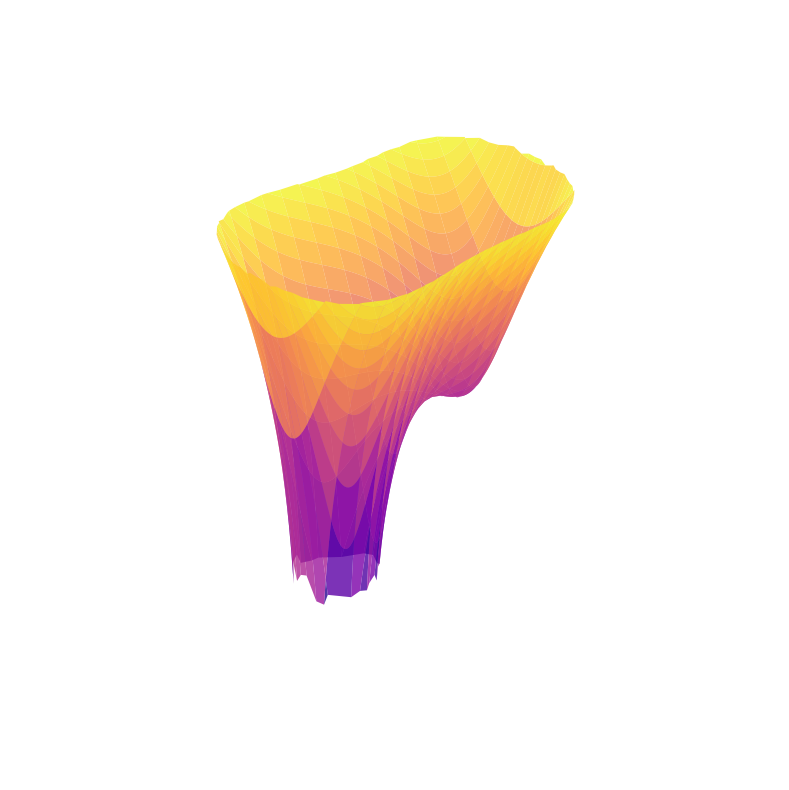

In [ ]:
import torch
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# Pool parameters
eps = 3.0
c = 1.0
d = 0.5

def energy(x):
	if len(x.shape) < 2:
		return eps * (c * (x[0]**2 - 1)**2 + (x[0] - x[1])**2 + d * (x[0] + x[1]))
	else:
		return eps * (c * (x[:, 0]**2 - 1)**2 + (x[:, 0] - x[:, 1])**2 + d * (x[:, 0] + x[:, 1]))

# Grid range - reduced resolution for better performance
pos_min, pos_max = -6, 6
x_vals = torch.linspace(pos_min, pos_max, 600)  # Reduced from 1000 to 200
y_vals = torch.linspace(pos_min, pos_max, 600)
X, Y = torch.meshgrid(x_vals, y_vals, indexing='ij')
points = torch.stack([X.flatten(), Y.flatten()], dim=1)

Z = energy(points).reshape(X.shape)

# Define the energy range you want to visualize
min_energy = 0
max_energy = 30

# Create mask for points within energy range
energy_mask = (Z >= min_energy) & (Z <= max_energy)

# Apply mask to coordinates and energy values
X_masked = torch.where(energy_mask, X, torch.nan)
Y_masked = torch.where(energy_mask, Y, torch.nan)
Z_masked = torch.where(energy_mask, Z, torch.nan)


# Apply logarithmic scaling to handle large energy values
Z_log_masked = torch.where(energy_mask, torch.log10(Z_masked + 1), torch.nan)

# Create the plot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot surface with masked values (NaN values won't be plotted)
surf = ax.plot_surface(X_masked.numpy(), Y_masked.numpy(), Z_log_masked.numpy(), 
					  cmap='plasma', alpha=0.8, edgecolor='none')

# Remove axes completely
ax.set_axis_off()

# Remove background panes and grid
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.xaxis.pane.set_edgecolor('none')
ax.yaxis.pane.set_edgecolor('none')
ax.zaxis.pane.set_edgecolor('none')

# Remove grid
ax.grid(False)

# Set transparent background for the figure
fig.patch.set_alpha(0.0)
ax.patch.set_alpha(0.0)

# Improve viewing angle
ax.view_init(elev=20, azim=240)

plt.tight_layout()

# Save with transparent background
plt.savefig('../resources/presentation/energy_surface.png', 
		   transparent=True,		   # Transparent background
		   bbox_inches='tight',		# Remove extra whitespace
		   pad_inches=0,			  # No padding
		   dpi=300)				   # High resolution

plt.show()

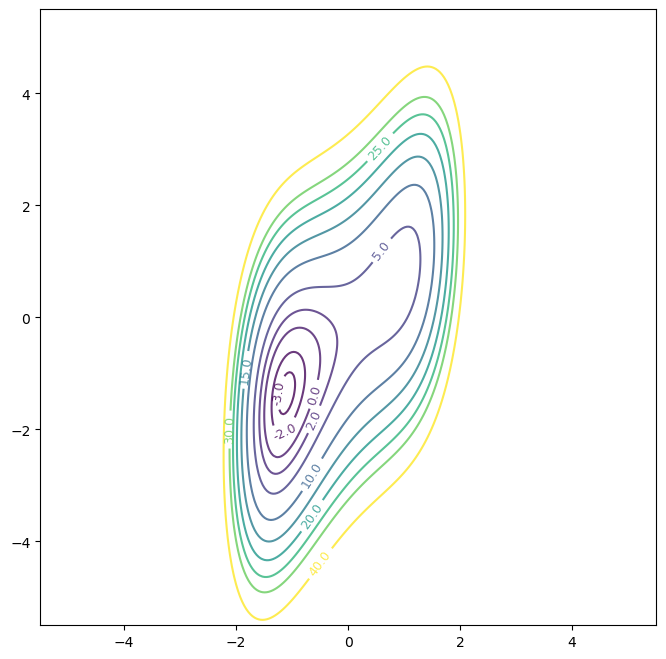

In [ ]:
# Contour plotting function
def plot_contour_lines_only(output_dir, energy_levels=None, colors=None, 
						   linewidths=None, linestyles=None, alpha=0.8):
	"""
	Plot specific contour lines only (no filled regions)
	
	Parameters:
	-----------
	output_dir : str
		Output directory and filename (without extension)
	energy_levels : list
		Specific energy levels to plot as contours
	colors : list or str
		Colors for each contour level
	linewidths : list or float
		Line widths for contours
	linestyles : list or str
		Line styles for contours
	alpha : float
		Transparency of contour lines
	"""
	# Default energy levels if not provided
	if energy_levels is None:
		energy_levels = [-3, -2, 0, 2, 5, 10, 15, 20, 25, 30, 40]
	
	# Define grid for visualization
	upper_lim, lower_lim = 5.5, -5.5
	x = np.linspace(lower_lim, upper_lim, 300)
	y = np.linspace(lower_lim, upper_lim, 300)
	X, Y = np.meshgrid(x, y)

	# Compute energy landscape
	Z_target = np.zeros([len(X), len(Y)])
	for i in range(len(X)):
		for j in range(len(Y)):
			conf = torch.tensor([X[i][j], Y[i][j]], dtype=torch.float32)
			Z_target[i, j] = energy(conf).item()

	# Create figure
	fig, ax = plt.subplots(figsize=(8, 8), dpi=100)

	# Set plot limits
	ax.set_xlim(lower_lim, upper_lim)
	ax.set_ylim(lower_lim, upper_lim)

	# Plot contour lines only
	contour = ax.contour(X, Y, Z_target, levels=energy_levels, 
						colors=colors, alpha=alpha, 
						linewidths=linewidths or 1.5,
						linestyles=linestyles or '-')
	
	# Add contour labels
	ax.clabel(contour, inline=True, fontsize=9, fmt='%.1f')
	
	# Set labels
	#ax.set_xlabel('x')
	#ax.set_ylabel('y')
	#ax.set_title('Energy Contour Lines')
	
	# Equal aspect ratio
	ax.set_aspect('equal')
	
	# Add grid for reference
	#ax.grid(True, alpha=0.3)
	
	# Save and close
	plt.savefig(output_dir + ".png", dpi=300, bbox_inches='tight')
	plt.show()  # Show instead of close for notebook

# Usage examples:
# Basic contour plot
plot_contour_lines_only("../resources/presentation/energy_contours")

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import glob
import os


In [ ]:

def load_energy_data(data_dir):
	"""
	Load energy vs time and energy vs calls data from DAT files
	
	Parameters:
	-----------
	data_dir : str
		Directory containing the DAT files
		
	Returns:
	--------
	time_data : dict
		Dictionary with keys: 'step', 'time', 'energy', 'acceptance', 'dx'
	calls_data : dict  
		Dictionary with keys: 'step', 'calls', 'energy'
	"""
	
	# Find the most recent energy vs time file
	time_files = glob.glob(os.path.join(data_dir, "energy_vs_time_*.dat"))
	if not time_files:
		raise FileNotFoundError(f"No energy_vs_time files found in {data_dir}")
	
	time_file = max(time_files, key=os.path.getctime)  # Most recent file
	print(f"Loading time data from: {time_file}")
	
	# Load energy vs time data
	time_data_raw = np.loadtxt(time_file)
	time_data = {
		'step': time_data_raw[:, 0],
		'time': time_data_raw[:, 1], 
		'energy': time_data_raw[:, 2],
		'acceptance': time_data_raw[:, 3],
		'dx': time_data_raw[:, 4]
	}
	
	# Find the most recent energy vs calls file
	calls_files = glob.glob(os.path.join(data_dir, "energy_vs_calls_*.dat"))
	if not calls_files:
		raise FileNotFoundError(f"No energy_vs_calls files found in {data_dir}")
	
	calls_file = max(calls_files, key=os.path.getctime)  # Most recent file
	print(f"Loading calls data from: {calls_file}")
	
	# Load energy vs calls data
	calls_data_raw = np.loadtxt(calls_file)
	calls_data = {
		'step': calls_data_raw[:, 0],
		'calls': calls_data_raw[:, 1],
		'energy': calls_data_raw[:, 2]
	}
	
	return time_data, calls_data

def plot_energy_vs_time(time_data, save_path=None):
	"""
	Plot energy vs time with secondary axis for acceptance ratio - plot only
	"""
	fig, ax1 = plt.subplots(figsize=(12, 6))
	
	# plot plot for energy vs time
	ax1.set_xlabel('Time (seconds)')
	ax1.set_ylabel(r'Energy $U_{max}$')
	plot1 = ax1.plot(time_data['time'], time_data['energy'], color='tab:red', alpha=0.8, label='Energy')
	ax1.grid(True, alpha=0.3)
	
	# Create secondary y-axis for acceptance ratio
	ax2 = ax1.twinx()
	ax2.set_ylabel('Acceptance Ratio')
	plot2 = ax2.plot(time_data['time'], time_data['acceptance'], color='tab:blue', s=0.2, alpha=0.7, label='Acceptance Ratio')
	ax2.set_ylim(0, 1)
	
	# Add legend
	ax1.legend([plot1, plot2], ['Energy', 'Acceptance Ratio'], loc='upper right')
	
	plt.title('Energy Evolution vs Time', fontweight='bold')
	plt.tight_layout()
	
	if save_path:
		plt.savefig(save_path, dpi=300, bbox_inches='tight')
		print(f"Saved energy vs time plot to: {save_path}")
	
	plt.show()

def plot_energy_vs_calls(calls_data, save_path=None):
	"""
	Plot energy vs number of function calls - plot only
	"""
	fig, ax = plt.subplots(figsize=(12, 6))
	
	# plot plot for energy vs calls
	ax.plot(calls_data['calls'], calls_data['energy'], color='tab:green', alpha=0.8, label='Energy')
	ax.set_xlabel('Total Energy Function Calls')
	ax.set_ylabel(r'Energy $U_{max}$')
	ax.grid(True, alpha=0.3)
	ax.legend()
	
	# Format x-axis to show calls in scientific notation if large
	if calls_data['calls'].max() > 1e6:
		ax.ticklabel_format(style='scientific', axis='x', scilimits=(0,0))
	
	plt.title('Energy Evolution vs Function Calls', fontweight='bold')
	plt.tight_layout()
	
	if save_path:
		plt.savefig(save_path, dpi=300, bbox_inches='tight')
		print(f"Saved energy vs calls plot to: {save_path}")
	
	plt.show()

def plot_both_comparisons(time_data, calls_data, save_path=None):
	"""
	Plot both comparisons in a single figure with subplots
	"""
	fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
	
	# Left plot: Energy vs Time
	color = 'tab:red'
	ax1.plot(time_data['time'], time_data['energy'], color=color, s=0.3)
	ax1.set_xlabel('Time (seconds)')
	ax1.set_ylabel(r'Energy $U_{max}$')
	ax1.tick_params(axis='y')
	ax1.grid(True, alpha=0.3)
	ax1.set_title('Energy vs Time', fontweight='bold')
	
	# Right plot: Energy vs Calls
	color = 'tab:green'
	ax2.plot(calls_data['calls'], calls_data['energy'], color=color, s=0.3)
	ax2.set_xlabel('Total Energy Function Calls')
	ax2.set_ylabel(r'Energy $U_{max}$')
	ax2.tick_params(axis='y')
	ax2.grid(True, alpha=0.3)
	ax2.set_title('Energy vs Function Calls', fontweight='bold')
	
	# Format x-axis for calls if large numbers
	if calls_data['calls'].max() > 1e6:
		ax2.ticklabel_format(style='scientific', axis='x', scilimits=(0,0))
	
	plt.tight_layout()
	
	if save_path:
		plt.savefig(save_path, dpi=300, bbox_inches='tight')
		print(f"Saved comparison plots to: {save_path}")
	
	plt.show()

In [10]:

# Set the directory containing your DAT files
data_directory = "../resources/nested_sampling_configs/"

try:
	# Load the data
	time_data, calls_data = load_energy_data(data_directory)
	
	# Plot separately
	plot_energy_vs_time(time_data, save_path="../resources/presentation/energy_vs_time.png")
	plot_energy_vs_calls(calls_data, save_path="../resources/presentation/energy_vs_calls.png")
	
	# Plot both together
	plot_both_comparisons(time_data, calls_data, save_path="../resources/presentation/energy_comparison.png")
	
	# Print some statistics
	print(f"\nData Summary:")
	print(f"Total runtime: {time_data['time'][-1]:.2f} seconds ({time_data['time'][-1]/60:.2f} minutes)")
	print(f"Total energy calls: {calls_data['calls'][-1]:.0f}")
	print(f"Initial energy: {time_data['energy'][0]:.2f}")
	print(f"Final energy: {time_data['energy'][-1]:.2f}")
	print(f"Energy reduction: {time_data['energy'][0] - time_data['energy'][-1]:.2f}")
	
except FileNotFoundError as e:
	print(f"Error: {e}")
	print("Make sure you have run the nested sampling algorithm first to generate the data files.")

Error: No energy_vs_time files found in ../resources/nested_sampling_configs/
Make sure you have run the nested sampling algorithm first to generate the data files.


In [14]:
def load_analysis_data(data_dir, algorithm_name=""):
	"""
	Load energy vs time and energy vs calls data from DAT files
	
	Parameters:
	-----------
	data_dir : str
		Directory containing the DAT files
	algorithm_name : str
		Name for logging purposes
		
	Returns:
	--------
	time_data : dict
		Dictionary with keys: 'step', 'time', 'energy', 'acceptance', 'dx'
	calls_data : dict  
		Dictionary with keys: 'step', 'sampl_type', 'calls', 'energy'
	"""
	
	# Find the most recent energy vs time file
	data_files = glob.glob(os.path.join(data_dir, "analysis_*.dat"))
	if not data_files:
		raise FileNotFoundError(f"No analysis files found in {data_dir}")
	
	data_file = max(data_files, key=os.path.getctime)  # Most recent file
	print(f"Loading {algorithm_name} time data from: {data_file}")
	
	# Load energy data
	data_raw = np.loadtxt(data_file)
	data = {
		'step': data_raw[:, 0],
		'sampl_type' : data_raw[:, 1],
		'time': data_raw[:, 2], 
		'calls' : data_raw[:, 3],
		'energy': data_raw[:, 4],
	}	
	
	return data

figsize = (4,3)
trio_figsize = (12,3)
dpi = 400 

def plot_segments_by_type(data, obs, ax=None, add_legend=True):
    """
    Plot energy vs calls with color segments by sampling type,
    ensuring no connections between different sampling types
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    
    # Get the sampling type array
    sampl_type = data['sampl_type']
    
    # Find indices where sampling type changes
    change_indices = np.where(sampl_type[1:] != sampl_type[:-1])[0] + 1
    
    # Add start and end indices
    segment_indices = np.concatenate(([0], change_indices, [len(sampl_type)]))
    
    # Plot each segment separately
    for i in range(len(segment_indices) - 1):
        start_idx = segment_indices[i]
        end_idx = segment_indices[i + 1]
        
        segment_type = sampl_type[start_idx]
        
        # Select color based on segment type
        if obs == 'calls' : 
            color = 'g' if segment_type == 0 else 'tab:brown'
        elif obs == 'step' : 
            color = 'b' if segment_type == 0 else 'm'
        else : 
            color = 'r' if segment_type == 0 else 'tab:orange'
        
        label = 'Nested Sampling (Mixed)' if segment_type == 0 else 'Pool Sampling (Mixed)'
        
        # Only add label for the first segment of each type
        if i > 0 and segment_type == sampl_type[segment_indices[i-1]]:
            label = None
        
        # Plot this segment
        ax.plot(
            data[obs][start_idx:end_idx],
            data['energy'][start_idx:end_idx],
            color=color,
            alpha=0.8,
            label=label
        )
    
    # Only add legend if requested
    if add_legend:
        handles, labels = ax.get_legend_handles_labels()
        unique_labels = dict(zip(labels, handles))
        ax.legend(unique_labels.values(), unique_labels.keys())
    
    if obs == 'calls' : ax.set_xlabel('Total Energy Function Calls')
    elif obs == 'step' : ax.set_xlabel('Iterations')
    else : ax.set_xlabel('Time (seconds)')

    ax.set_ylabel(r'Energy $U_{max}$')
    ax.grid(True, alpha=0.3)
    
    # Format x-axis to show calls in scientific notation
    ax.ticklabel_format(style='scientific', axis='x', scilimits=(0,0))
    
    return ax
def plot_all_nested(data, save_path=None):
	"""
	Plot both energy vs time and energy vs calls in a single figure with subplots
	"""
	fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=trio_figsize)
	
	# first plot: Energy vs Time
	ax1.plot(data['time'], data['energy'], color='tab:red')
	ax1.set_xlabel('Time (seconds)')
	ax1.set_ylabel(r'Energy $U_{max}$')
	ax1.grid(True, alpha=0.3)
	ax1.set_title('Energy vs Time', fontweight='bold')
	
	# second plot: Energy vs iteration
	ax2.plot(data['step'], data['energy'], color='tab:green')
	ax2.set_xlabel('Iterations')
	ax2.set_ylabel(r'Energy $U_{max}$')
	ax2.grid(True, alpha=0.3)
	ax2.set_title('Energy vs Iterations', fontweight='bold')
	
	# third plot: Energy vs Calls
	ax3.plot(data['calls'], data['energy'], color='tab:blue')
	ax3.set_xlabel('Energy function calls')
	ax3.set_ylabel(r'Energy $U_{max}$')
	ax3.grid(True, alpha=0.3)
	ax3.set_title('Energy vs Function calls', fontweight='bold')
	
	# Format x-axis for calls if large numbers
	if data['calls'].max() > 1e4:
		ax2.ticklabel_format(style='scientific', axis='x', scilimits=(0,0))
	
	plt.tight_layout()
	
	if save_path:
		plt.savefig(save_path, dpi=dpi, bbox_inches='tight')
		print(f"Saved comparison plots to: {save_path}")
	
	plt.show()

def plot_all_mixed(data, save_path=None):
	"""
	Plot both energy vs time and energy vs calls in a single figure with subplots
	"""
	fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=trio_figsize)
	
	# first plot: Energy vs Time
	ax1 = plot_segments_by_type(data, 'time', ax=ax1)
	ax1.set_title('Energy vs Time', fontweight='bold')
	
	# second plot: Energy vs iteration
	ax2 = plot_segments_by_type(data, 'step', ax=ax2)
	ax2.set_title('Energy vs Iterations', fontweight='bold')
	
	# third plot: Energy vs Calls
	ax3 = plot_segments_by_type(data, 'calls', ax=ax3)
	ax3.set_title('Energy vs Function calls', fontweight='bold')
	
	plt.tight_layout()
	
	if save_path:
		plt.savefig(save_path, dpi=dpi, bbox_inches='tight')
		print(f"Saved comparison plots to: {save_path}")
	
	plt.show()

def plot_comparison(nested_data, mixed_data, save_path=None):
    """
    Plot direct side-by-side comparison of both algorithms
    with properly segmented sampling type lines for time and calls
    """
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=trio_figsize)
    
    # Left plot: Energy vs Time comparison
    ax1.plot(nested_data['time'], nested_data['energy'], 
             color='tab:blue', alpha=0.8, label='Nested Sampling (Pure)')
    
    # Mixed routine with segmentation by sampling type for time plot (no auto-legend)
    plot_segments_by_type(mixed_data, 'time', ax=ax1, add_legend=False)
    
    # Manually create legend with proper order
    ax1.legend(['Nested Sampling (Pure)', 'Nested Sampling (Mixed)', 'Pool Sampling (Mixed)'])
    ax1.set_title('Energy vs Time', fontweight='bold')
    
    # Center plot: Energy vs step comparison 
    ax2.plot(nested_data['step'], nested_data['energy'], 
             color='tab:blue', alpha=0.8, label='Nested Sampling (Pure)')
    
    # Mixed routine with segmentation by sampling type for step plot (no auto-legend)
    plot_segments_by_type(mixed_data, 'step', ax=ax2, add_legend=False)
    
    # Manually create legend with proper order
    ax2.legend(['Nested Sampling (Pure)', 'Nested Sampling (Mixed)', 'Pool Sampling (Mixed)'])
    ax2.set_title('Energy vs Iterations', fontweight='bold')

    # Right plot: Energy vs calls comparison
    ax3.plot(nested_data['calls'], nested_data['energy'], 
             color='tab:blue', alpha=0.8, label='Nested Sampling (Pure)')
    
    # Mixed routine with segmentation by sampling type for calls plot (no auto-legend)
    plot_segments_by_type(mixed_data, 'calls', ax=ax3, add_legend=False)
    
    # Manually create legend with proper order
    ax3.legend(['Nested Sampling (Pure)', 'Nested Sampling (Mixed)', 'Pool Sampling (Mixed)'])
    ax3.set_title('Energy vs Calls', fontweight='bold')

    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=dpi, bbox_inches='tight')
        print(f"Saved side-by-side comparison to: {save_path}")
    
    plt.show()
def print_comparison_summary(nested_data, mixed_data):
	"""
	Print comparative statistics between algorithms - with scientific notation
	"""
	print("\n" + "="*60)
	print("ALGORITHM COMPARISON SUMMARY")
	print("="*60)
	
	print(f"\n{'Metric':<25} {'Nested Sampling (Mixed)':<20} {'Mixed Routine':<20}")
	print("-" * 65)
	
	# Runtime comparison
	nested_time = nested_data['time'][-1]
	mixed_time = mixed_data['time'][-1]
	print(f"{'Total Runtime (s)':<25} {nested_time:<20.2e} {mixed_time:<20.2e}")
	print(f"{'Total Runtime (min)':<25} {nested_time/60:<20.2e} {mixed_time/60:<20.2e}")
	
	# Energy calls comparison
	nested_calls = nested_data['calls'][-1]
	mixed_calls = mixed_data['calls'][-1]
	print(f"{'Total Energy Calls':<25} {nested_calls:<20.2e} {mixed_calls:<20.2e}")
	
	# Energy reduction comparison
	nested_initial = nested_data['energy'][0]
	nested_final = nested_data['energy'][-1]
	mixed_initial = mixed_data['energy'][0]
	mixed_final = mixed_data['energy'][-1]
	
	print(f"{'Initial Energy':<25} {nested_initial:<20.2e} {mixed_initial:<20.2e}")
	print(f"{'Final Energy':<25} {nested_final:<20.2e} {mixed_final:<20.2e}")
	print(f"{'Energy Reduction':<25} {nested_initial-nested_final:<20.2e} {mixed_initial-mixed_final:<20.2e}")
	
	# Efficiency metrics
	nested_efficiency = (nested_initial-nested_final) / nested_time
	mixed_efficiency = (mixed_initial-mixed_final) / mixed_time
	print(f"{'Energy Reduction/Time':<25} {nested_efficiency:<20.2e} {mixed_efficiency:<20.2e}")
	
	nested_call_efficiency = (nested_initial-nested_final) / nested_calls
	mixed_call_efficiency = (mixed_initial-mixed_final) / mixed_calls
	print(f"{'Energy Reduction/Call':<25} {nested_call_efficiency:<20.2e} {mixed_call_efficiency:<20.2e}")
	
	print("\n" + "="*60)

Loading Nested Sampling time data from: ../resources/nested_sampling_configs/metrics/analysis_20250618_160522.dat
Loading Mixed Routine time data from: ../resources/mixed_routine/last_live_samples/conditioned/metrics/analysis_20250618_170050.dat
Saved comparison plots to: ../resources/presentation/nested_comparison.png


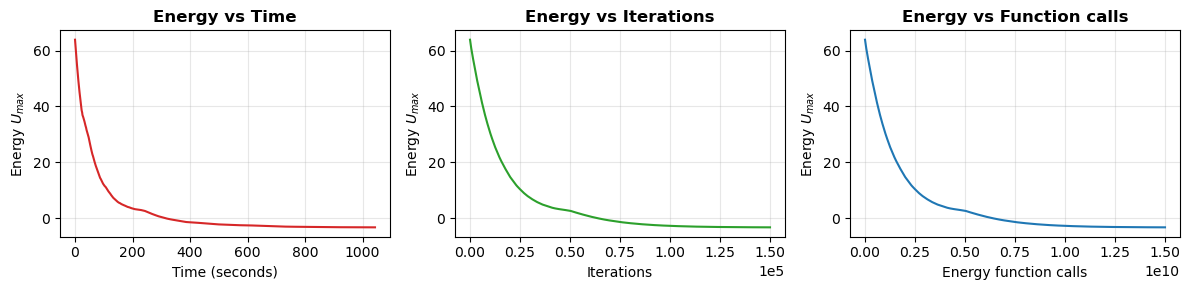

Saved comparison plots to: ../resources/presentation/mixed_comparison.png


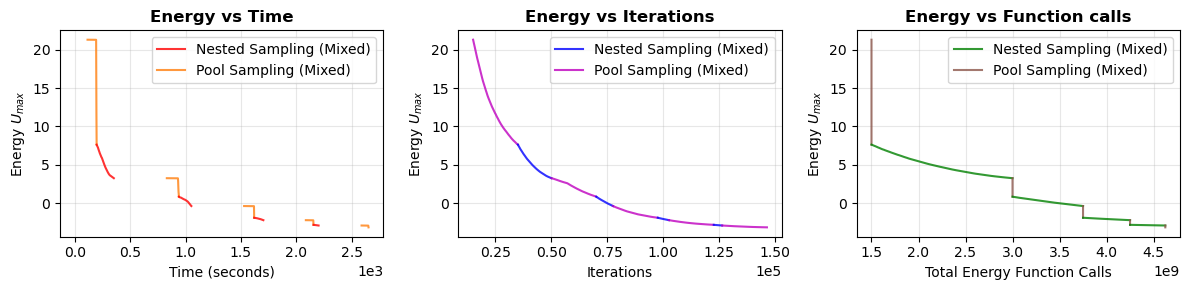

Saved side-by-side comparison to: ../resources/presentation/algorithms_comparison.png


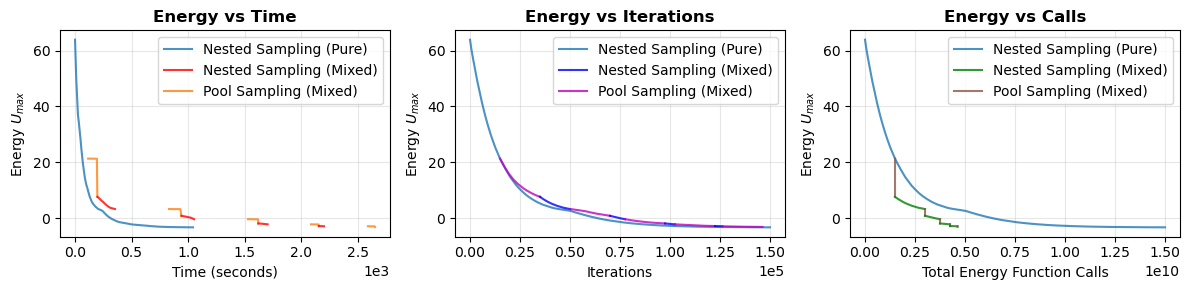


ALGORITHM COMPARISON SUMMARY

Metric                    Nested Sampling (Mixed) Mixed Routine       
-----------------------------------------------------------------
Total Runtime (s)         1.04e+03             2.65e+03            
Total Runtime (min)       1.74e+01             4.42e+01            
Total Energy Calls        1.50e+10             4.63e+09            
Initial Energy            6.39e+01             2.13e+01            
Final Energy              -3.31e+00            -3.17e+00           
Energy Reduction          6.72e+01             2.45e+01            
Energy Reduction/Time     6.45e-02             9.24e-03            
Energy Reduction/Call     4.48e-09             5.30e-09            



In [15]:
# Directories for both algorithms
nested_dir = "../resources/nested_sampling_configs/metrics/"
mixed_dir = "../resources/mixed_routine/last_live_samples/conditioned/metrics/"

try:
	# Load data using the new combined structure
	nested_data = load_analysis_data(nested_dir, "Nested Sampling")
	mixed_data = load_analysis_data(mixed_dir, "Mixed Routine")
	
	# Create comparison plots
	plot_all_nested(nested_data, save_path="../resources/presentation/nested_comparison.png")
	plot_all_mixed(mixed_data, save_path="../resources/presentation/mixed_comparison.png")
	
	plot_comparison(nested_data, mixed_data,
							 save_path="../resources/presentation/algorithms_comparison.png")
	
	# Print comparative statistics
	print_comparison_summary(nested_data, mixed_data)
		
except FileNotFoundError as e:
	print(f"Error: {e}")
	print("Make sure both algorithms have been run and generated their data files.")